<a href="https://colab.research.google.com/github/Afif-Ghifari/PCVK_2025/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>MODUL 10 – Thresholding, Segmentasi Sederhana</h1>
<hr>
<h2>Percobaan Praktikum</h2>

<b>Nama : Muhammad Afif Al Ghifari</b><br>
<b>Kelas: TI-3H</b><br>
<b>NIM  : 2341720168</b>

## Tugas Praktikum

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan
threshold= 170, secara manual sesuai dengan deskripsi dari grafik yang ditunjukkan di
atas.

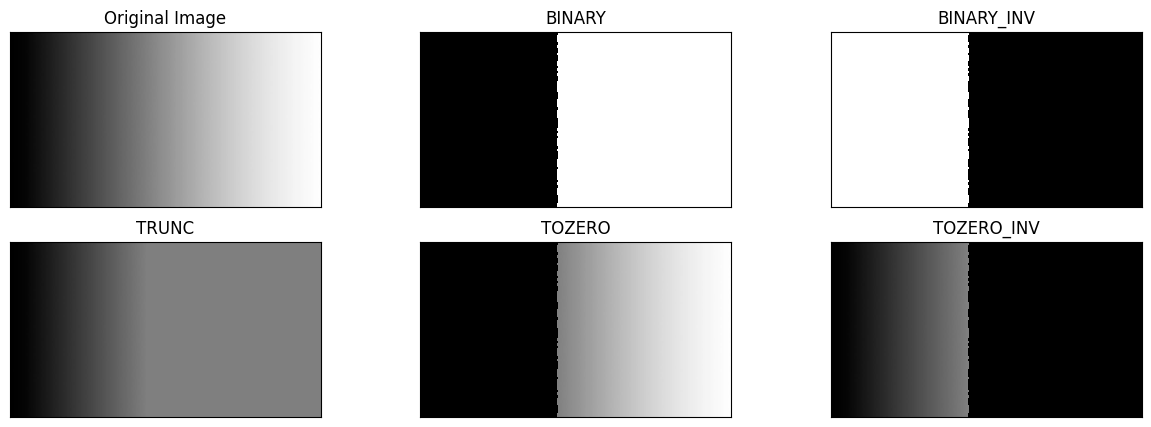

In [ ]:
filename = ('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/gradient.jpg')
img = cv2.imread(filename)
thresh = 127      #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
ret,thresh1 = cv2.threshold(img,thresh,255,cv2.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv2.threshold(img,thresh,255,cv2.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv2.threshold(img,thresh,255,cv2.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv2.threshold(img,thresh,255,cv2.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv2.threshold(img,thresh,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

Buat Otsu Thresholding tanpa menggunakan Library. Tampilkan juga nilai threshold
saat anda gunakan Otsu’s, seperti terlihat pada gambar hasil berikut. (gunakan image
balloon.jpg agar terlihat beda antara hasil otsu’s dengan global threshold biasa)

Nilai threshold Otsu: 175


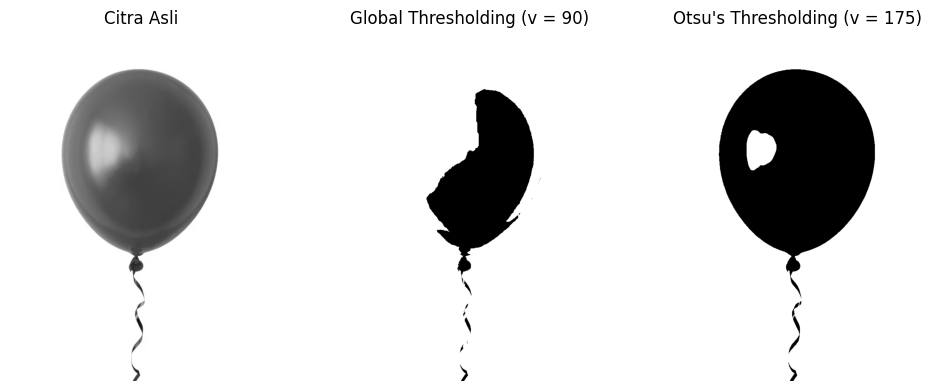

In [ ]:
img = cv2.imread("/content/drive/MyDrive/kuliah/pcvk/asset pcvk/balloon.jpg", cv2.IMREAD_GRAYSCALE)
def otsu_threshold(image):
    pixel_counts, _ = np.histogram(image, bins=256, range=(0, 256))
    total_pixels = image.size

    sum_total = np.dot(np.arange(256), pixel_counts)
    sum_background = 0
    weight_background = 0
    max_variance = 0
    threshold = 0

    for t in range(256):
        weight_background += pixel_counts[t]
        if weight_background == 0:
            continue
        weight_foreground = total_pixels - weight_background
        if weight_foreground == 0:
            break
        sum_background += t * pixel_counts[t]
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground
        variance_between = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2
        if variance_between > max_variance:
            max_variance = variance_between
            threshold = t
    return threshold

otsu_t = otsu_threshold(img)
print("Nilai threshold Otsu:", otsu_t)
global_t = 90
_, global_thresh = cv2.threshold(img, global_t, 255, cv2.THRESH_BINARY)
_, otsu_thresh = cv2.threshold(img, otsu_t, 255, cv2.THRESH_BINARY)
titles = [
    "Citra Asli",
    f"Global Thresholding (v = {global_t})",
    f"Otsu's Thresholding (v = {otsu_t})"
]
images = [img, global_thresh, otsu_thresh]

plt.figure(figsize=(10, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


Buat histogram dari citra tersegmentasi, Histogram hanya pada foreground image saja. Gunakan image tobacco.jpg yang sudah disediakan di folder images. Petunjuk:  
- anda dapat gunakan cv.calcHist untuk menampilkan histogram.
- Buka link berikut https://opencvtutorial.readthedocs.io/en/latest/histogram/histogram.html
- Dari link tersebut perhatikan bahwa cv.calcHist memiliki salah satu parameter yaitu mask. Jika diset None, maka keseluruhan image akan dihitung histogramnya.Jika kita tentukan mask, maka hanya bagian image yang dimasking warna putih yang akan dihitung histogramnya (dari contoh dibawah dinamakan dengan Citra Segment).

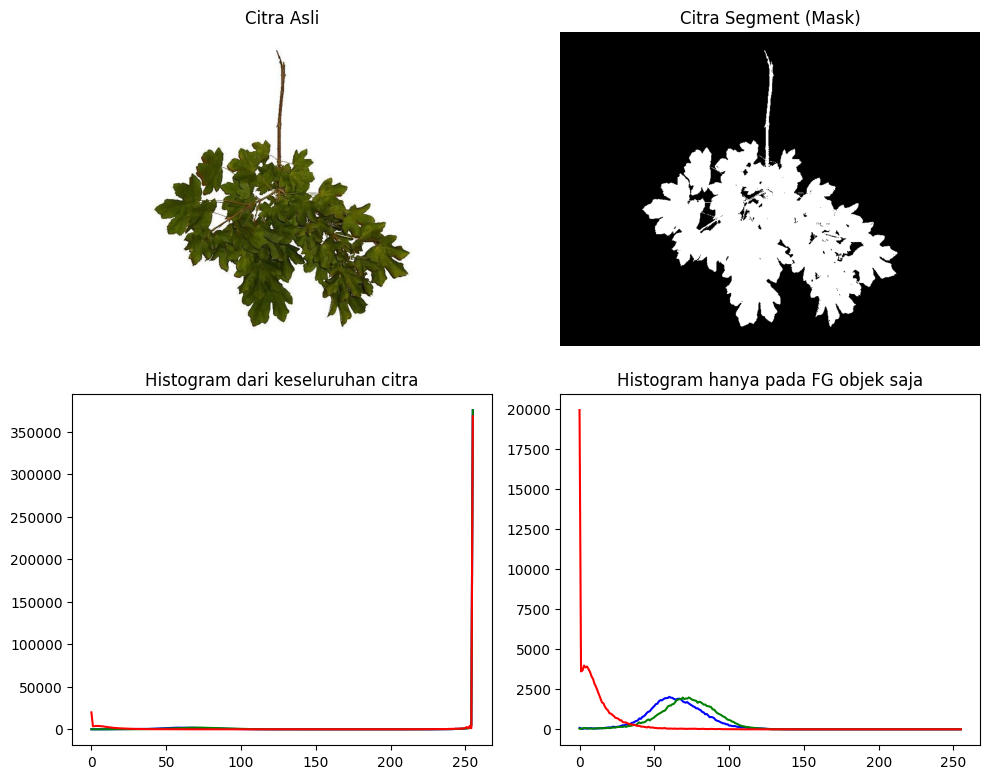

In [ ]:
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/leaves.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
colors = ('b', 'g', 'r')

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Citra Segment (Mask)")
plt.axis('off')

# Histogram keseluruhan citra (tanpa mask)
plt.subplot(2, 2, 3)
for i, col in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
plt.title("Histogram dari keseluruhan citra")

# Histogram hanya pada foreground (bagian objek)
plt.subplot(2, 2, 4)
for i, col in enumerate(colors):
    hist_fg = cv2.calcHist([img_rgb], [i], mask, [256], [0, 256])
    plt.plot(hist_fg, color=col)
plt.title("Histogram hanya pada FG objek saja")

plt.tight_layout()
plt.show()

Lakukan segmentasi warna pada image "peppers.jpg", munculkan hanya warna yang
kuning saja. (Petunjuk: anda dapat gunakan K-Means untuk menampilkan hanya
warna tertentu saja). Saat anda menampilkan warna tertentu, jelaskan kendala yang di hadapi dan mengapa
hal itu terjadi.

Cluster warna kuning berada pada indeks: 2
Warna pusat cluster: [250 206   3]


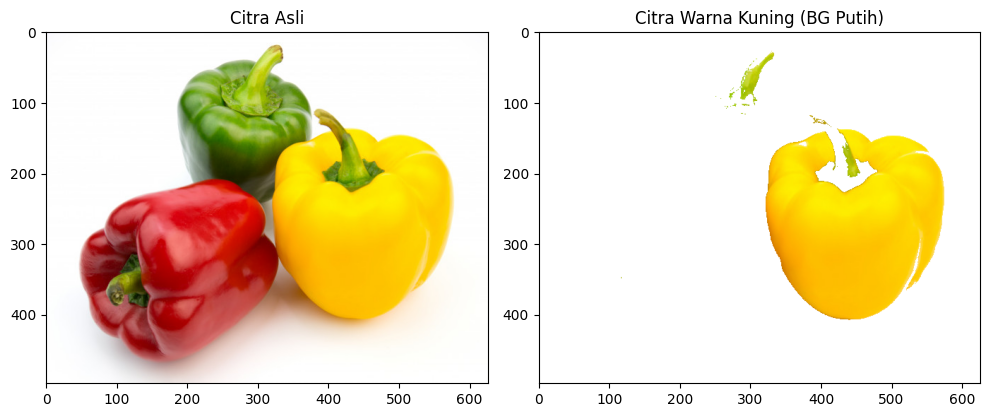

In [ ]:
from sklearn.cluster import KMeans
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/peppers.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Ubah ke dalam bentuk array 2D (pixel list)
pixels = img_rgb.reshape((-1, 3))
pixels = np.float32(pixels)

# Tentukan jumlah cluster (misal 3 warna utama)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixels)
labels = kmeans.labels_
centers = np.uint8(kmeans.cluster_centers_)

# Tentukan cluster warna kuning
yellow = np.array([255, 255, 0])
distances = np.linalg.norm(centers - yellow, axis=1)
yellow_cluster = np.argmin(distances)
print("Cluster warna kuning berada pada indeks:", yellow_cluster)
print("Warna pusat cluster:", centers[yellow_cluster])

# Buat citra baru: foreground kuning, background putih
mask = (labels == yellow_cluster)
segmented_img = np.ones_like(pixels) * 255
segmented_img[mask] = pixels[mask]
segmented_img = segmented_img.reshape(img_rgb.shape).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Citra Asli")

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title("Citra Warna Kuning (BG Putih)")

plt.tight_layout()
plt.show()

Saat menampilkan warna kuning, ada sedikit warna hijau yang tertangkap setelah segentasi. Hal ini dikarenakan warna kuning dan warna hijau berada bersebelahan di ruang warna RGB maupun HSV

Buka File crossword.jpg. Dengan pengetahuan tentang thresholding yang sudah anda pelajari. Lakukan thresholding biner dengan hasil terbaik menurut anda. Copas code dan hasil image di modul ini.

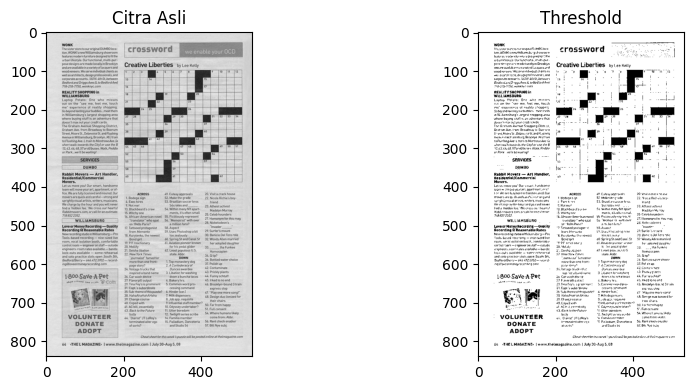

In [ ]:
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/crossword.jpg', cv2.IMREAD_GRAYSCALE)
thresh = 127

ret,threshCrossword = cv2.threshold(img,thresh,255,cv2.THRESH_BINARY)

# Tampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Citra Asli")

plt.subplot(1, 2, 2)
plt.imshow(threshCrossword, cmap="gray")
plt.title("Threshold")

plt.tight_layout()
plt.show()